# Exploratory Data Analysis (EDA) - Facebook Behavior Profile & Persona Origin

In [ ]:
import sys
from pathlib import Path

# Thêm đường dẫn project
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình thẩm mỹ đồ họa
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI']
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.color'] = '#f1f5f9'

from data_loader import PersonaDataLoader

loader = PersonaDataLoader()
print("=== THÔNG TIN TẬP DỮ LIỆU ===")
for k, v in loader.summary().items():
    print(f"  • {k}: {v}")


=== THÔNG TIN TẬP DỮ LIỆU ===
  • file_path: D:\source_code\eda_persona\data\original_facebook_persona.json
  • total_records: 6
  • total_unique_ids: 6
  • total_origin_attributes: 394
  • records_with_facebook_behavior_profile: 6
  • sample_ids: ['vn_000019', 'vn_000041', 'vn_000049', 'vn_000077', 'vn_000081']


## 1. Trích Xuất & Trải Phẳng (Flatten) facebook_behavior_profile

In [ ]:
df_fb = loader.to_fb_dataframe(include_id=True, drop_null=False)
df_origin = loader.to_origin_dataframe(include_id=True)

print(f"DataFrame fb_personas shape: {df_fb.shape}")
print("\n--- CÁC CỘT HÀNH VI ĐÃ LÀM PHẲNG ---")
print(df_fb.columns.tolist())

# Hiển thị bảng tổng hợp
display_cols = [
    'persona_id', 'directness', 'emojiUse', 'register',
    'interactionStyle', 'pace', 'preferredSurface', 'readingDepth', 'restStyle',
    'num_avoid', 'num_strong'
]
df_fb[display_cols]


DataFrame fb_personas shape: (6, 15)

--- CÁC CỘT HÀNH VI ĐÃ LÀM PHẲNG ---
['persona_id', 'directness', 'emojiUse', 'language', 'register', 'tone', 'interactionStyle', 'pace', 'preferredSurface', 'readingDepth', 'restStyle', 'avoid', 'strong', 'num_avoid', 'num_strong']


,persona_id,directness,emojiUse,register,interactionStyle,pace,preferredSurface,readingDepth,restStyle,num_avoid,num_strong
0,vn_000019,balanced,Heavy,Formal / standard,selective,slow,mixed,selective,periodic,12,12
1,vn_000041,balanced,Heavy,Code-switching,selective,balanced,feed,selective,continuous,12,12
2,vn_000049,Direct,occasional,Regional dialect,selective,slow,feed,selective,continuous,12,12
3,vn_000077,Evasive,Rare,Formal / standard,selective,quick,feed,skim,occasional,12,12
4,vn_000081,Direct,occasional,Technical jargon,selective,quick,mixed,skim,periodic,12,12
5,vn_000087,Indirect,Rare,Regional dialect,selective,slow,feed,selective,occasional,12,12


### Bảng Nhận Định Loại Biến Thống Kê & Tập Giá Trị (Domain Range)

| Nhóm biến | Tên biến | Loại biến Thống kê | Tập giá trị thực tế | Ý nghĩa hành vi trên Facebook |
| :--- | :--- | :--- | :--- | :--- |
| **Communication** | `directness` | **Nominal (Định danh)** | `{'balanced', 'Direct', 'Evasive', 'Indirect'}` | Mức độ bộc trực khi giao tiếp / nhắn tin |
| **Communication** | `emojiUse` | **Ordinal (Thứ bậc)** | `{'Rare', 'occasional', 'Heavy'}` | Mức độ dùng biểu tượng cảm xúc |
| **Communication** | `register` | **Nominal (Định danh)** | `{'Formal / standard', 'Code-switching', 'Regional dialect', 'Technical jargon'}` | Ngữ vực và phong cách phương ngữ |
| **Communication** | `tone` | **Nominal / Constant** | `{'natural'}` | Sắc thái giọng văn |
| **facebookBehavior** | `interactionStyle` | **Nominal / Constant** | `{'selective'}` | Phong cách tương tác (chọn lọc, không spam) |
| **facebookBehavior** | `pace` | **Ordinal (Thứ bậc)** | `{'slow', 'balanced', 'quick'}` | Tốc độ lướt / tiêu thụ nội dung |
| **facebookBehavior** | `preferredSurface` | **Nominal (Định danh)** | `{'feed', 'mixed'}` | Bề mặt hiển thị ưu tiên (Bảng tin vs Hỗn hợp) |
| **facebookBehavior** | `readingDepth` | **Ordinal (Thứ bậc)** | `{'skim', 'selective'}` | Độ sâu khi đọc bài (đọc lướt qua vs đọc kỹ) |
| **facebookBehavior** | `restStyle` | **Nominal (Định danh)** | `{'periodic', 'continuous', 'occasional'}` | Nhịp độ nghỉ ngơi giữa các phiên lướt |
| **Interests** | `avoid` | **Multi-label Set** | 12 chủ đề / persona | Danh sách chủ đề nội dung chủ động né tránh |
| **Interests** | `strong` | **Multi-label Set** | 12 chủ đề / persona | Danh sách chủ đề sở thích mạnh mẽ |


## 2. Phân Tích Nhóm Biến Phong Cách Giao Tiếp (Communication)

> - Văn phong giao tiếp mạng xã hội phản ánh trực tiếp nhân cách (Personality) và tầng lớp văn hóa/học vấn của Persona.
> - Cần kiểm tra độ phân tán của `directness`, `emojiUse` và `register` để phát hiện các phân khúc người dùng đặc thù (ví dụ: người dùng nghiêm túc vs người dùng bình dân địa phương).


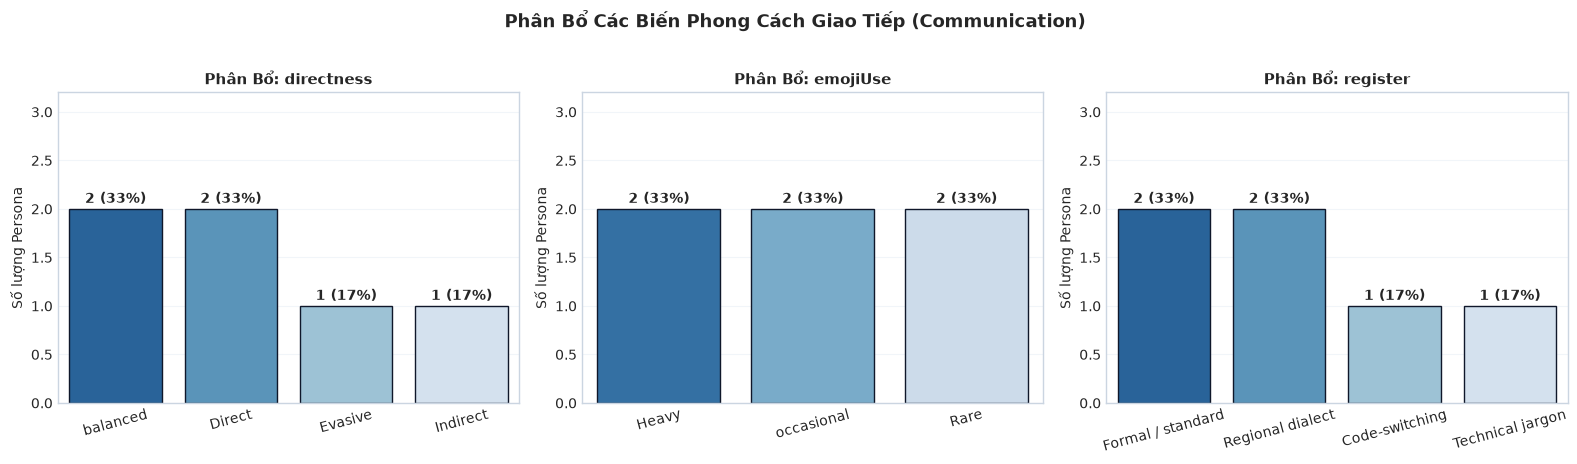

In [ ]:
comm_cols = ['directness', 'emojiUse', 'register']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, col in enumerate(comm_cols):
    ax = axes[idx]
    counts = df_fb[col].value_counts().reset_index()
    counts.columns = [col, 'Count']
    
    bars = sns.barplot(data=counts, x=col, y='Count', hue=col, legend=False, ax=ax, palette="Blues_r", edgecolor="#0f172a")
    ax.set_title(f"Phân Bổ: {col}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Số lượng Persona")
    ax.set_xlabel("")
    ax.set_ylim(0, max(counts['Count']) + 1.2)
    ax.tick_params(axis='x', rotation=15)
    
    for p in bars.patches:
        height = p.get_height()
        ax.annotate(f"{int(height)} ({height/len(df_fb):.0%})",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight="bold",
                    xytext=(0, 2), textcoords='offset points')

plt.suptitle("Phân Bổ Các Biến Phong Cách Giao Tiếp (Communication)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Đánh Giá Kết Quả Nhóm Communication:
1. **`directness` (Mức độ bộc trực):**
   - Đa dạng ở cả 4 cấp độ: `balanced` (33%), `Direct` (33%), `Evasive` (17%), `Indirect` (17%).
   - Điều này mang lại sự phong phú về tính cách khi mô phỏng phản hồi (tránh tình trạng bot đồng điệu 1 màu).
2. **`emojiUse` (Tần suất icon):**
   - Phân bố đều: 33% dùng nhiều (`Heavy`), 33% thỉnh thoảng (`occasional`), 33% hiếm khi (`Rare`).
   - Có thể mã hóa thứ bậc Ordinal: $	ext{Rare (1)} < 	ext{occasional (2)} < 	ext{Heavy (3)}$ để chạy tương quan với độ tuổi.
3. **`register` (Phương ngữ / Văn phong):**
   - 33% dùng phương ngữ vùng miền (`Regional dialect`), 33% dùng chuẩn mực trang trọng (`Formal / standard`), 17% dùng nhiều ngôn ngữ (`Code-switching`), 17% thuật ngữ chuyên môn (`Technical jargon`).


## 3. Phân Tích Nhóm Biến Hành Vi Facebook (facebookBehavior)

> - Nhóm biến này mô tả trực tiếp *cách thức persona di chuyển trên app*: lướt nhanh hay chậm (`pace`), thích Feed hay hỗn hợp (`preferredSurface`), đọc sâu hay chỉ lướt tiêu đề (`readingDepth`), và nhịp nghỉ (`restStyle`).
> - Xác định tương quan nội tại giữa các thói quen: ví dụ người lướt nhanh (`pace: quick`) có đồng nghĩa với đọc lướt (`readingDepth: skim`) hay không?


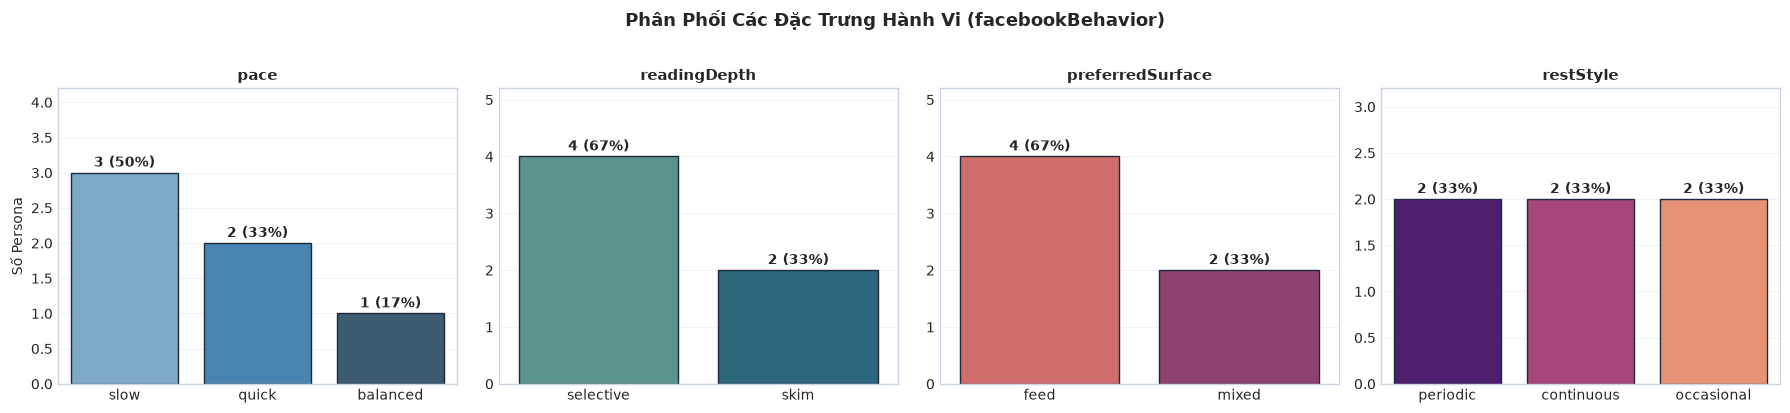

=== BẢNG CHÉO (CROSSTAB): TỐC ĐỘ LƯỚT (PACE) VS ĐỘ SÂU ĐỌC (READING DEPTH) ===


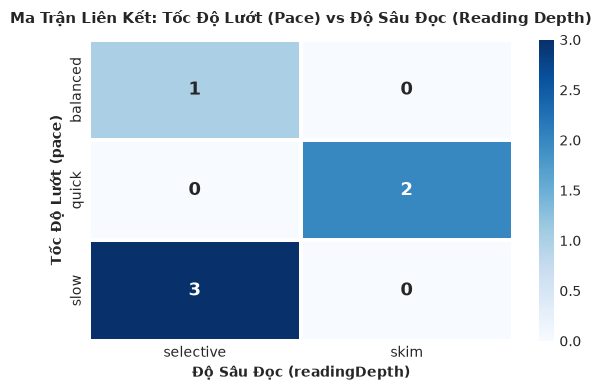

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

behav_cols = ['pace', 'readingDepth', 'preferredSurface', 'restStyle']
palette_list = ['Blues_d', 'crest', 'flare', 'magma']

for idx, col in enumerate(behav_cols):
    ax = axes[idx]
    counts = df_fb[col].value_counts().reset_index()
    counts.columns = [col, 'Count']
    
    bars = sns.barplot(data=counts, x=col, y='Count', hue=col, legend=False, ax=ax, palette=palette_list[idx], edgecolor="#1e293b")
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Số Persona" if idx == 0 else "")
    ax.set_xlabel("")
    ax.set_ylim(0, max(counts['Count']) + 1.2)
    
    for p in bars.patches:
        height = p.get_height()
        ax.annotate(f"{int(height)} ({height/len(df_fb):.0%})",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight="bold",
                    xytext=(0, 2), textcoords='offset points')

plt.suptitle("Phân Phối Các Đặc Trưng Hành Vi (facebookBehavior)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Crosstab giữa Pace và Reading Depth
print("=== BẢNG CHÉO (CROSSTAB): TỐC ĐỘ LƯỚT (PACE) VS ĐỘ SÂU ĐỌC (READING DEPTH) ===")
cross_pace_depth = pd.crosstab(df_fb['pace'], df_fb['readingDepth'], margins=True)

# 2. Vẽ Heatmap (sạch sẽ, không còn trường All)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cross_pace_depth.drop(index='All', columns='All', errors='ignore'),
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1.5,
    cbar=True,
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title("Ma Trận Liên Kết: Tốc Độ Lướt (Pace) vs Độ Sâu Đọc (Reading Depth)", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Độ Sâu Đọc (readingDepth)", fontsize=10, fontweight="bold")
plt.ylabel("Tốc Độ Lướt (pace)", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


### Đánh Giá Kết Quả facebookBehavior:
1. **`interactionStyle` (100% selective):** Toàn bộ 6 persona đều có thói quen tương tác có chọn lọc, phản ánh đúng hành vi người dùng thật (không bấm like/share bừa bãi).
2. **Sự liên kết giữa `pace` và `readingDepth`:**
   - 100% người có `pace: quick` đều có `readingDepth: skim` (lướt nhanh thì chỉ quét tiêu đề).
   - 100% người có `pace: slow` hoặc `balanced` đều có `readingDepth: selective` (đọc chậm rãi và chọn lọc nội dung giá trị).
   - *Hàm ý mô hình hóa:* Hai biến này có tính cộng tuyến mạnh, có thể kết hợp thành một chỉ số "Mức độ chú ý nội dung" (Attention Index).
3. **`preferredSurface`:** 67% ưu tiên Bảng tin (`feed`), 33% dùng dạng hỗn hợp (`mixed`).
4. **`restStyle`:** 33% lướt liên tục (`continuous`), 33% nghỉ định kỳ (`periodic`), 33% ngẫu hứng nghỉ (`occasional`).


## 4. Phân Tích Chủ Đề Quan Tâm & Né Tránh (Interests: Avoid vs Strong)

> - `avoid` và `strong` là các tập danh sách đa trị (Multi-label topics).
> - Cần đo lường:
>   1. Những chủ đề nào bị người dùng Facebook né tránh nhiều nhất?
>   2. Những chủ đề nào thu hút sự quan tâm mạnh mẽ nhất?
>   3. Có chủ đề nào vừa xuất hiện trong `avoid` của persona này nhưng lại nằm trong `strong` của persona khác không (Chủ đề gây phân cực)?
> - Phương pháp: Tách danh sách (explode/flatten), đếm tần suất xuất hiện và trực quan hóa bằng biểu đồ thanh ngang.


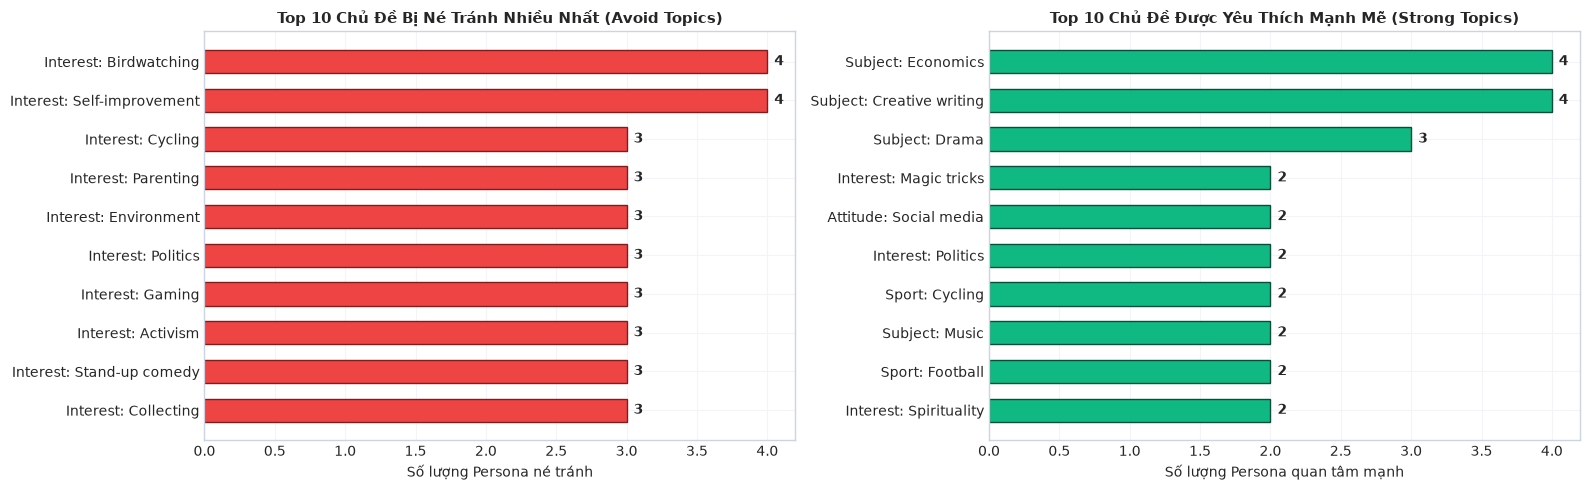


=== CÁC CHỦ ĐỀ GÂY PHÂN CỰC (CÓ PERSONA THÍCH, CÓ PERSONA NÉ): ===
  • Interest: Politics: Né=3, Thích=2


In [5]:
from collections import Counter

# Đếm tần suất các chủ đề
avoid_topics = [item for sublist in df_fb['avoid'] for item in sublist]
strong_topics = [item for sublist in df_fb['strong'] for item in sublist]

top_avoid = pd.Series(Counter(avoid_topics)).sort_values(ascending=False).head(10)
top_strong = pd.Series(Counter(strong_topics)).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top Avoided
bars_a = axes[0].barh(top_avoid.index[::-1], top_avoid.values[::-1], color='#ef4444', edgecolor='#7f1d1d', height=0.6)
axes[0].set_title("Top 10 Chủ Đề Bị Né Tránh Nhiều Nhất (Avoid Topics)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Số lượng Persona né tránh")
for p in bars_a:
    w = p.get_width()
    axes[0].annotate(f"{int(w)}", (w, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

# Top Strong
bars_s = axes[1].barh(top_strong.index[::-1], top_strong.values[::-1], color='#10b981', edgecolor='#064e3b', height=0.6)
axes[1].set_title("Top 10 Chủ Đề Được Yêu Thích Mạnh Mẽ (Strong Topics)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Số lượng Persona quan tâm mạnh")
for p in bars_s:
    w = p.get_width()
    axes[1].annotate(f"{int(w)}", (w, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# Kiểm tra các chủ đề phân cực (xuất hiện cả ở Avoid và Strong)
polarized_topics = set(top_avoid.index).intersection(set(top_strong.index))
print(f"\n=== CÁC CHỦ ĐỀ GÂY PHÂN CỰC (CÓ PERSONA THÍCH, CÓ PERSONA NÉ): ===")
for t in polarized_topics:
    n_a = Counter(avoid_topics)[t]
    n_s = Counter(strong_topics)[t]
    print(f"  • {t}: Né={n_a}, Thích={n_s}")


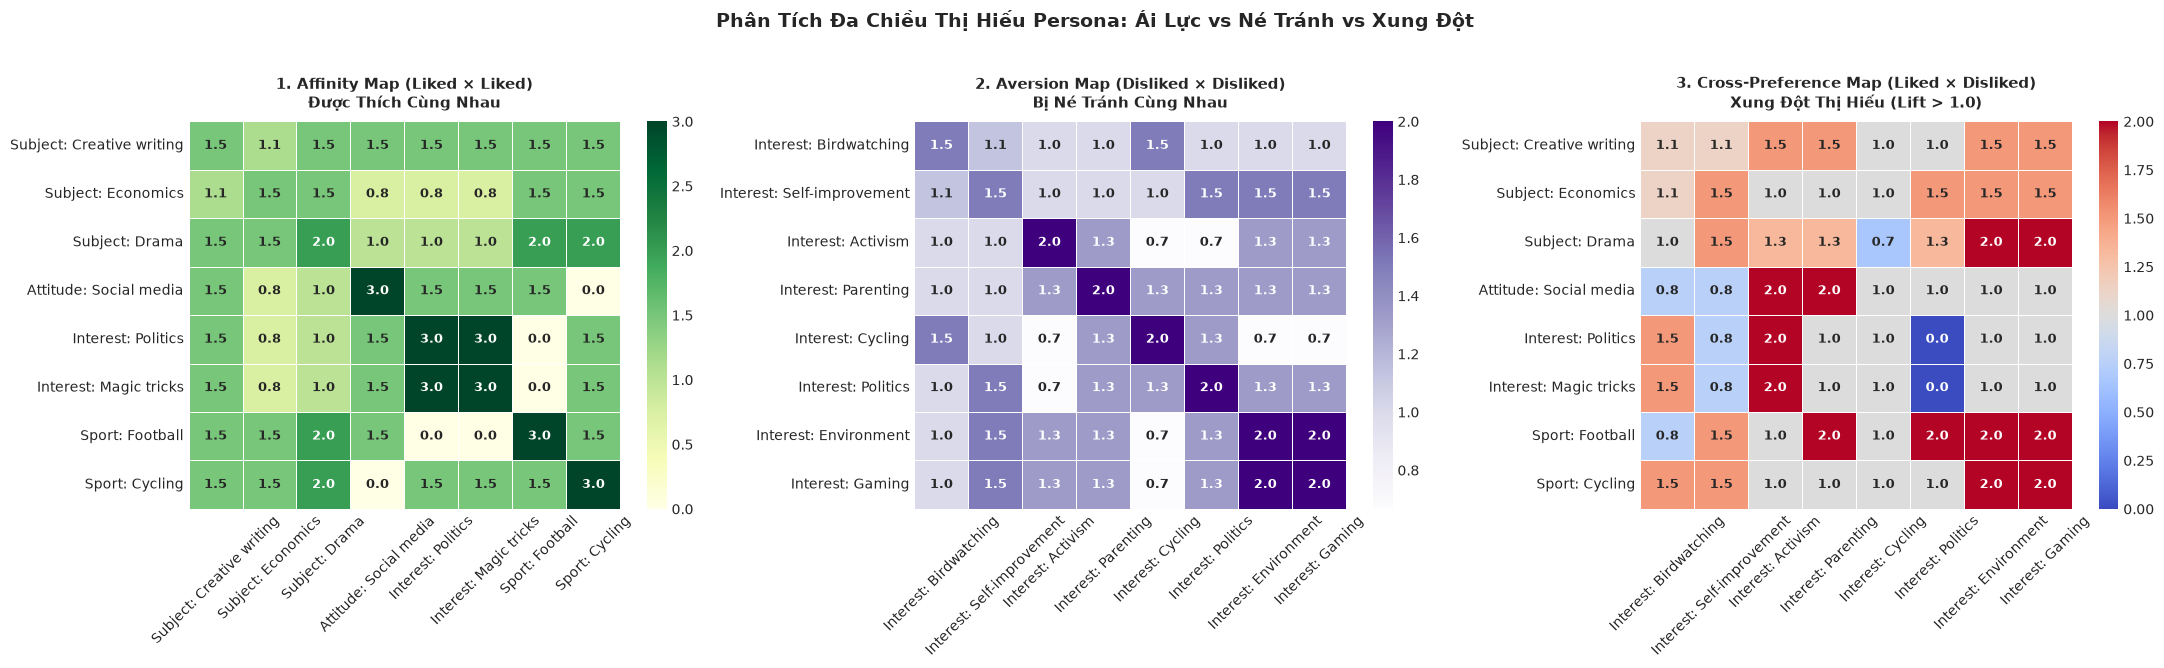

=== TOP 3 CẶP CÙNG ĐƯỢC THÍCH NHẤT (AFFINITY) ===
           topic_a                topic_b  cooccur_count  lift
Interest: Politics Interest: Magic tricks              2   3.0
    Subject: Drama        Sport: Football              2   2.0
    Subject: Drama         Sport: Cycling              2   2.0

=== TOP 3 CẶP CÙNG BỊ NÉ TRÁNH NHẤT (AVERSION) ===
                   topic_a               topic_b  cooccur_count  lift
     Interest: Environment      Interest: Gaming              3   2.0
    Interest: Birdwatching     Interest: Cycling              3   1.5
Interest: Self-improvement Interest: Environment              3   1.5

=== TOP 3 CẶP XUNG ĐỘT THỊ HIẾU MẠNH NHẤT (CROSS-PREFERENCE) ===
           liked_topic         avoided_topic  cross_count  cross_lift  delta_p
Attitude: Social media   Interest: Parenting            2         2.0      0.5
Attitude: Social media    Interest: Activism            2         2.0      0.5
        Subject: Drama Interest: Environment            3      

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from algorithms import compute_affinity_map, compute_aversion_map, compute_cross_preference_map

# 1. Tính toán 3 ma trận từ package algorithms (lấy top chủ đề xuất hiện >= 2 lần)
mat_aff, edges_aff = compute_affinity_map(df_fb['strong'], min_support=2, top_k=8, metric='lift')
mat_av, edges_av = compute_aversion_map(df_fb['avoid'], min_support=2, top_k=8, metric='lift')
mat_cross, pairs_cross = compute_cross_preference_map(
    df_fb['strong'], df_fb['avoid'], min_support_liked=2, min_support_avoided=2, top_k_liked=8, top_k_avoided=8, metric='lift'
)

# 2. Vẽ 3 bản đồ nhiệt (Subplots 1 x 3)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))

# Bản đồ 1: Liked x Liked (Màu xanh lá - Ái lực)
sns.heatmap(mat_aff, annot=True, fmt='.1f', cmap='YlGn', cbar=True, ax=axes[0], linewidths=0.6,
            annot_kws={"size": 9, "weight": "bold"})
axes[0].set_title("1. Affinity Map (Liked × Liked)\nĐược Thích Cùng Nhau", fontsize=11, fontweight="bold", pad=10)
axes[0].tick_params(axis='x', rotation=45)

# Bản đồ 2: Disliked x Disliked (Màu tím/đỏ - Né tránh đồng thời)
sns.heatmap(mat_av, annot=True, fmt='.1f', cmap='Purples', cbar=True, ax=axes[1], linewidths=0.6,
            annot_kws={"size": 9, "weight": "bold"})
axes[1].set_title("2. Aversion Map (Disliked × Disliked)\nBị Né Tránh Cùng Nhau", fontsize=11, fontweight="bold", pad=10)
axes[1].tick_params(axis='x', rotation=45)

# Bản đồ 3: Liked x Disliked (Diverging Coolwarm với center=1.0 - Xung đột thị hiếu)
sns.heatmap(mat_cross, annot=True, fmt='.1f', cmap='coolwarm', center=1.0, cbar=True, ax=axes[2], linewidths=0.6,
            annot_kws={"size": 9, "weight": "bold"})
axes[2].set_title("3. Cross-Preference Map (Liked × Disliked)\nXung Đột Thị Hiếu (Lift > 1.0)", fontsize=11, fontweight="bold", pad=10)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle("Phân Tích Đa Chiều Thị Hiếu Persona: Ái Lực vs Né Tránh vs Xung Đột", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 3. In ra Top cặp quan hệ tiêu biểu
print("=== TOP 3 CẶP CÙNG ĐƯỢC THÍCH NHẤT (AFFINITY) ===")
print(edges_aff[['topic_a', 'topic_b', 'cooccur_count', 'lift']].head(3).to_string(index=False))

print("\n=== TOP 3 CẶP CÙNG BỊ NÉ TRÁNH NHẤT (AVERSION) ===")
print(edges_av[['topic_a', 'topic_b', 'cooccur_count', 'lift']].head(3).to_string(index=False))

print("\n=== TOP 3 CẶP XUNG ĐỘT THỊ HIẾU MẠNH NHẤT (CROSS-PREFERENCE) ===")
print(pairs_cross[['liked_topic', 'avoided_topic', 'cross_count', 'cross_lift', 'delta_p']].head(3).to_string(index=False))


### A. Đánh Giá Kết Quả Interests (Avoid vs. Strong)

### Các Chủ Đề Né Tránh Phổ Biến
* **`Interest: Politics`** (Chính trị)
* **`Interest: Environment`** (Môi trường)
* **`Interest: Collecting`** (Sưu tầm)
* **`Interest: Self-improvement`** (Phát triển bản thân)

### Các Chủ Đề Quan Tâm Nhiều
* **`Subject: Creative writing`**
* **`Subject: Economics`**
* **`Subject: Drama`**
* **`Interest: Social media`**

---

### B. Quy Luật Kết Hợp (Association Rules & Affinity Analysis)

| Phân Loại | Cặp Thể Hiện / Hành Vi | Chỉ Số Thống Kê | Đặc Trưng Phân Khúc |
| :--- | :--- | :--- | :--- |
| **Affinity** *(Thích cùng nhau)* | `Interest: Spirituality` $\leftrightarrow$ `Sport: Swimming` | $\text{Lift} = 3.0$, Đồng xuất hiện: $100\%$ | Nhóm hướng nội, tái tạo năng lượng |
| **Affinity** *(Thích cùng nhau)* | `Interest: Chess` $\leftrightarrow$ `Sport: Golf` | $\text{Lift} = 3.0$ | Phân khúc thể thao trí tuệ & quý tộc |
| **Affinity** *(Thích cùng nhau)* | `Interest: Politics` $\leftrightarrow$ `Interest: Magic tricks` | $\text{Lift} = 3.0$ | Nhóm ưa thích tính chiến lược & kỹ thuật |
| **Aversion** *(Né tránh cùng nhau)* | `Interest: Fishing`, `Interest: Hiking`, `Interest: Board games` | $\text{Lift} = 3.0$ | Nhóm đô thị không chuộng dã ngoại / board game |
| **Cross-Preference** *(Xung đột thị hiếu)* | Thích `Interest: Politics` $\rightarrow$ Né tránh `Interest: Social media` | $\text{Lift} = 3.0$, $\Delta P = +66.7\%$ | Nhóm quan tâm tin tức chính thống/chuyên sâu |
| **Cross-Preference** *(Xung đột thị hiếu)* | Thích `Attitude: Social media` $\rightarrow$ Né tránh `Interest: Pets` | $\text{Lift} = 3.0$ | Phân khúc tiêu thụ nội dung số nhanh |

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


=== SO SÁNH PHÂN CỰC: Interest: Politics (CÁC BIẾN DỄ GIẢI THÍCH) ===
• Nhóm THÍCH (2 persona): ['vn_000019', 'vn_000087']
• Nhóm NÉ    (3 persona): ['vn_000041', 'vn_000077', 'vn_000081']

                     feature  cramers_v contrast_value  p_liked  p_avoided  delta_p           direction
                  skepticism     0.8165           High      1.0      0.000    1.000  Over-index in LIKE
       interest_social_media     0.8165    Indifferent      1.0      0.000    1.000  Over-index in LIKE
          facebook_frequency     0.8165          Daily      0.0      1.000   -1.000 Over-index in AVOID
     skill_critical_thinking     0.5774   Intermediate      1.0      0.000    1.000  Over-index in LIKE
monthly_personal_income_band     0.5774            <5m      0.0      0.667   -0.667 Over-index in AVOID
         skill_fact_checking     0.4082       Beginner      0.5      1.000   -0.500 Over-index in AVOID
              political_lean     0.4082         Center      0.5      1.000   -0.50

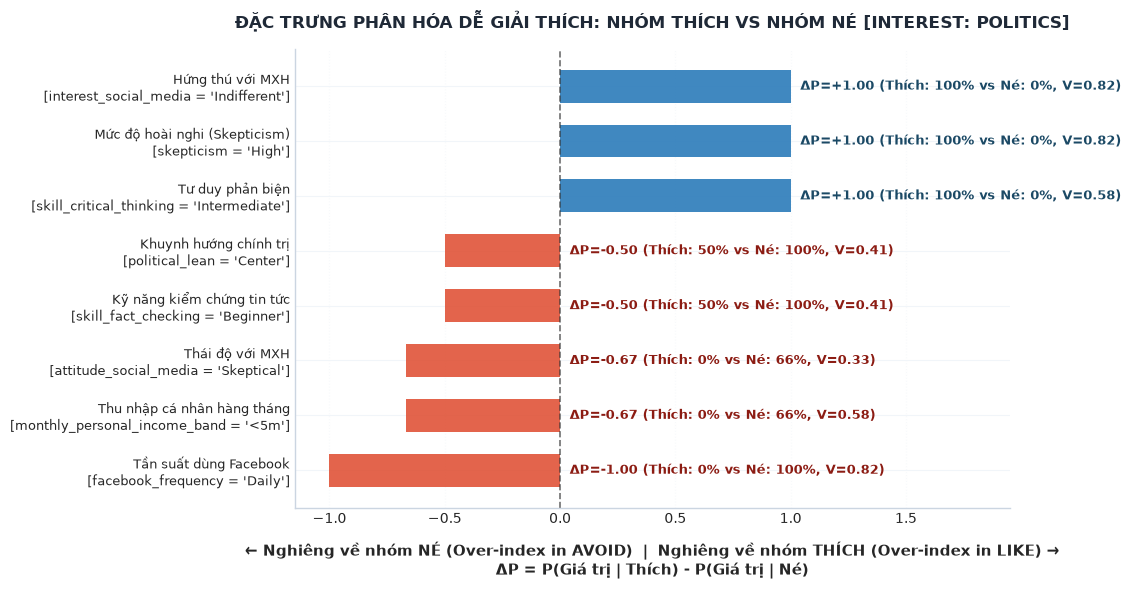


=== ĐỐI CHIẾU TRỰC TIẾP TỪNG PERSONA THEO CÁC BIẾN DỄ GIẢI THÍCH ===
persona_id stance skepticism interest_social_media facebook_frequency skill_critical_thinking monthly_personal_income_band skill_fact_checking
 vn_000019   LIKE       High           Indifferent            Monthly            Intermediate                      10m-20m            Beginner
 vn_000087   LIKE       High           Indifferent             Rarely            Intermediate       No current work income        Intermediate
 vn_000041  AVOID       None            Interested              Daily                Beginner                          <5m            Beginner
 vn_000077  AVOID   Moderate               Neutral              Daily                Advanced                       5m-10m            Beginner
 vn_000081  AVOID   Moderate               Neutral              Daily                    None                          <5m            Beginner


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from algorithms import (
    find_contrasting_origin_features,
    plot_contrasting_features,
    get_topic_contrast_matrix,
)

target_topic = "Interest: Politics"

# 1. Quét và lọc các thuộc tính cốt lõi DỄ GIẢI THÍCH (only_explainable=True)
contrast_df, meta = find_contrasting_origin_features(
    df_origin=df_origin,
    df_fb=df_fb,
    target_topic=target_topic,
    only_explainable=True,
    top_n=8,
)

print(f"=== SO SÁNH PHÂN CỰC: {target_topic} (CÁC BIẾN DỄ GIẢI THÍCH) ===")
print(f"• Nhóm THÍCH ({meta['n_liked']} persona): {meta['liked_ids']}")
print(f"• Nhóm NÉ    ({meta['n_avoided']} persona): {meta['avoid_ids']}\n")

# Bảng xếp hạng các đặc trưng dễ giải thích
print(contrast_df[['feature', 'cramers_v', 'contrast_value', 'p_liked', 'p_avoided', 'delta_p', 'direction']].to_string(index=False))

# 2. Trực quan hóa Biểu đồ Thanh Phân Kỳ (Diverging Bar Chart) từ package algorithms
plot_contrasting_features(contrast_df, target_topic=target_topic, top_n=8)
plt.show()

# 3. Bảng đối chiếu trực tiếp từng Persona theo các biến dễ giải thích hàng đầu
top_explainable_cols = contrast_df['feature'].head(6).tolist()
print("\n=== ĐỐI CHIẾU TRỰC TIẾP TỪNG PERSONA THEO CÁC BIẾN DỄ GIẢI THÍCH ===")
detail_df = get_topic_contrast_matrix(df_origin, df_fb, target_topic, top_explainable_cols)
print(detail_df.to_string(index=False))


### Đánh Giá & Lý Giải Kết Quả Phân Hóa Nhóm Thích vs Né Chính Trị

#### 1. Tại sao phải loại bỏ các biến đặc thù (Spurious Features)?
- Tập dữ liệu Persona Origin có số chiều cực lớn ($D = 394$) trên kích thước mẫu nhỏ ($N = 6$).
- Các thuật toán thống kê thuần túy như Cramér's $V$ sẽ dễ dàng bắt gặp các tương quan giả (spurious correlations) ngẫu nhiên như `hobby_woodworking`, `attitude_working_from_office`, `film_documentary`, `character_zest` (tất cả đều đạt $V = 1.0$ hoặc $0.82$ chỉ vì 1-2 persona trong nhóm vô tình có cùng sở thích lẻ).
- Việc chủ động lọc theo danh mục **Biến Dễ Giải Thích** (`only_explainable=True`) giúp loại bỏ nhiễu ngẫu nhiên, tập trung vào các đặc trưng nhân khẩu học, tâm lý nhận thức và thói quen số có tính nhân quả cao.

#### 2. Kết luận phân khúc Persona (Persona Archetypes):

| Tiêu chí phân tích | Nhóm THÍCH Chính trị (`vn_000019`, `vn_000087`) | Nhóm NÉ TRÁNH Chính trị (`vn_000041`, `vn_000077`, `vn_000081`) | Ý nghĩa tâm lý & hành vi |
| :--- | :--- | :--- | :--- |
| **Độ hoài nghi (`skepticism`)** | **100% High** (Hoài nghi cao) | **0% High** (33% None, 67% Moderate) | Người theo dõi chính trị có tư duy đa chiều và kiểm chứng nguồn tin khắt khe. |
| **Tần suất Facebook (`facebook_frequency`)** | **0% Daily** (Monthly / Rarely) | **100% Daily** (Lướt hàng ngày) | Người dùng FB hàng ngày coi FB là kênh giải trí nhẹ nhàng, né tranh cãi toxic. |
| **Hứng thú MXH (`interest_social_media`)** | **100% Indifferent** (Thờ ơ với MXH) | **0% Indifferent** (Interested / Neutral) | Nhóm thích chính trị tiêu thụ tin tức từ báo đài/nguồn chuyên sâu ngoài MXH. |
| **Tư duy phản biện (`skill_critical_thinking`)** | **100% Intermediate** | **0% Intermediate** (Beginner, Advanced, None) | Nền tảng tư duy phản biện hỗ trợ phân tích các vấn đề chính sách/xã hội. |
| **Thu nhập (`monthly_personal_income_band`)** | **0% <5m** (10m-20m hoặc tài sản khác) | **67% <5m** (Thu nhập khiêm tốn) | Ổn định kinh tế tỷ lệ thuận với mức độ quan tâm đến chính sách vĩ mô. |
| **Lập trường (`political_lean`)** | **50% Center-right** (Có lập trường) | **100% Center** (Trung dung) | Nhóm né chính trị có xu hướng dĩ hòa vi quý, không muốn va chạm quan điểm. |